### Лабораториска вежба 2


---

Линеарна Регресија, Lasso Регресија и Ridge
Регресија

In [30]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt # Библиотека за визуелизација
import seaborn as sns
import numpy as np # Библиотека за нумерички анализи
import pandas as pd
from scipy import stats # Библиотека за статистички анализи
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # Min max Scaler за нормализација на податоци во опсег [0,1]
from sklearn.linear_model import LinearRegression  # Вчитување на модели за линерна регресија
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # За евалуација на модели

1. Читање на податочното множество и анализа


---



In [31]:
df = pd.read_csv('/content/Student_Performance.csv')
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Правиме preprocessing бидејќи колоната "Extracurricular Activities" е категориска променлива, а машинските модели, односно во овој слулај линеарната регресија работи само со нумерички променливи, затоа правиме preprocessing.

In [33]:
df['Extracurricular Activities']=np.where(df['Extracurricular Activities']=="Yes",1,0)

In [34]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [35]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [36]:
X = df.drop('Performance Index', axis=1) # Х матрицата одговара на влезните вектори, каде што секој ред одговара на податочна точка, а секоја колона одговара на карактеристика (атрибут)
y = df['Performance Index'] # Векторот y одговара на излезните вредности, каде што i-тата вредност е класата на i-тиот вектор на атрибут (ред) во X
number_of_features=X.shape[1]
number_of_targets=1
feature_names = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
target_names = ['Performance Index']
print("Имиња на излезните класи: ", target_names)
N = X.shape[0]

print("Број на карактеристики (атрибути): ", X.shape[1]) #бројот на атрибути одговара на бројот на колони во X матрицата
print("Број на излезни класи: ", len(target_names)) # или number_of_targets
print("Број на инстанци: ", X.shape[0]) # или N

Имиња на излезните класи:  ['Performance Index']
Број на карактеристики (атрибути):  5
Број на излезни класи:  1
Број на инстанци:  10000


Може да заклучиме дека станува збор за мултиваријантна линеарна регресија (има повеќе features). Имаме независни и зависни променливи, односно независни се ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced'] и зависната променлива е таргетот, то ест 'Performance Index', всушност тоа сакаме да го предвидиме.

2. Визуелизации

---



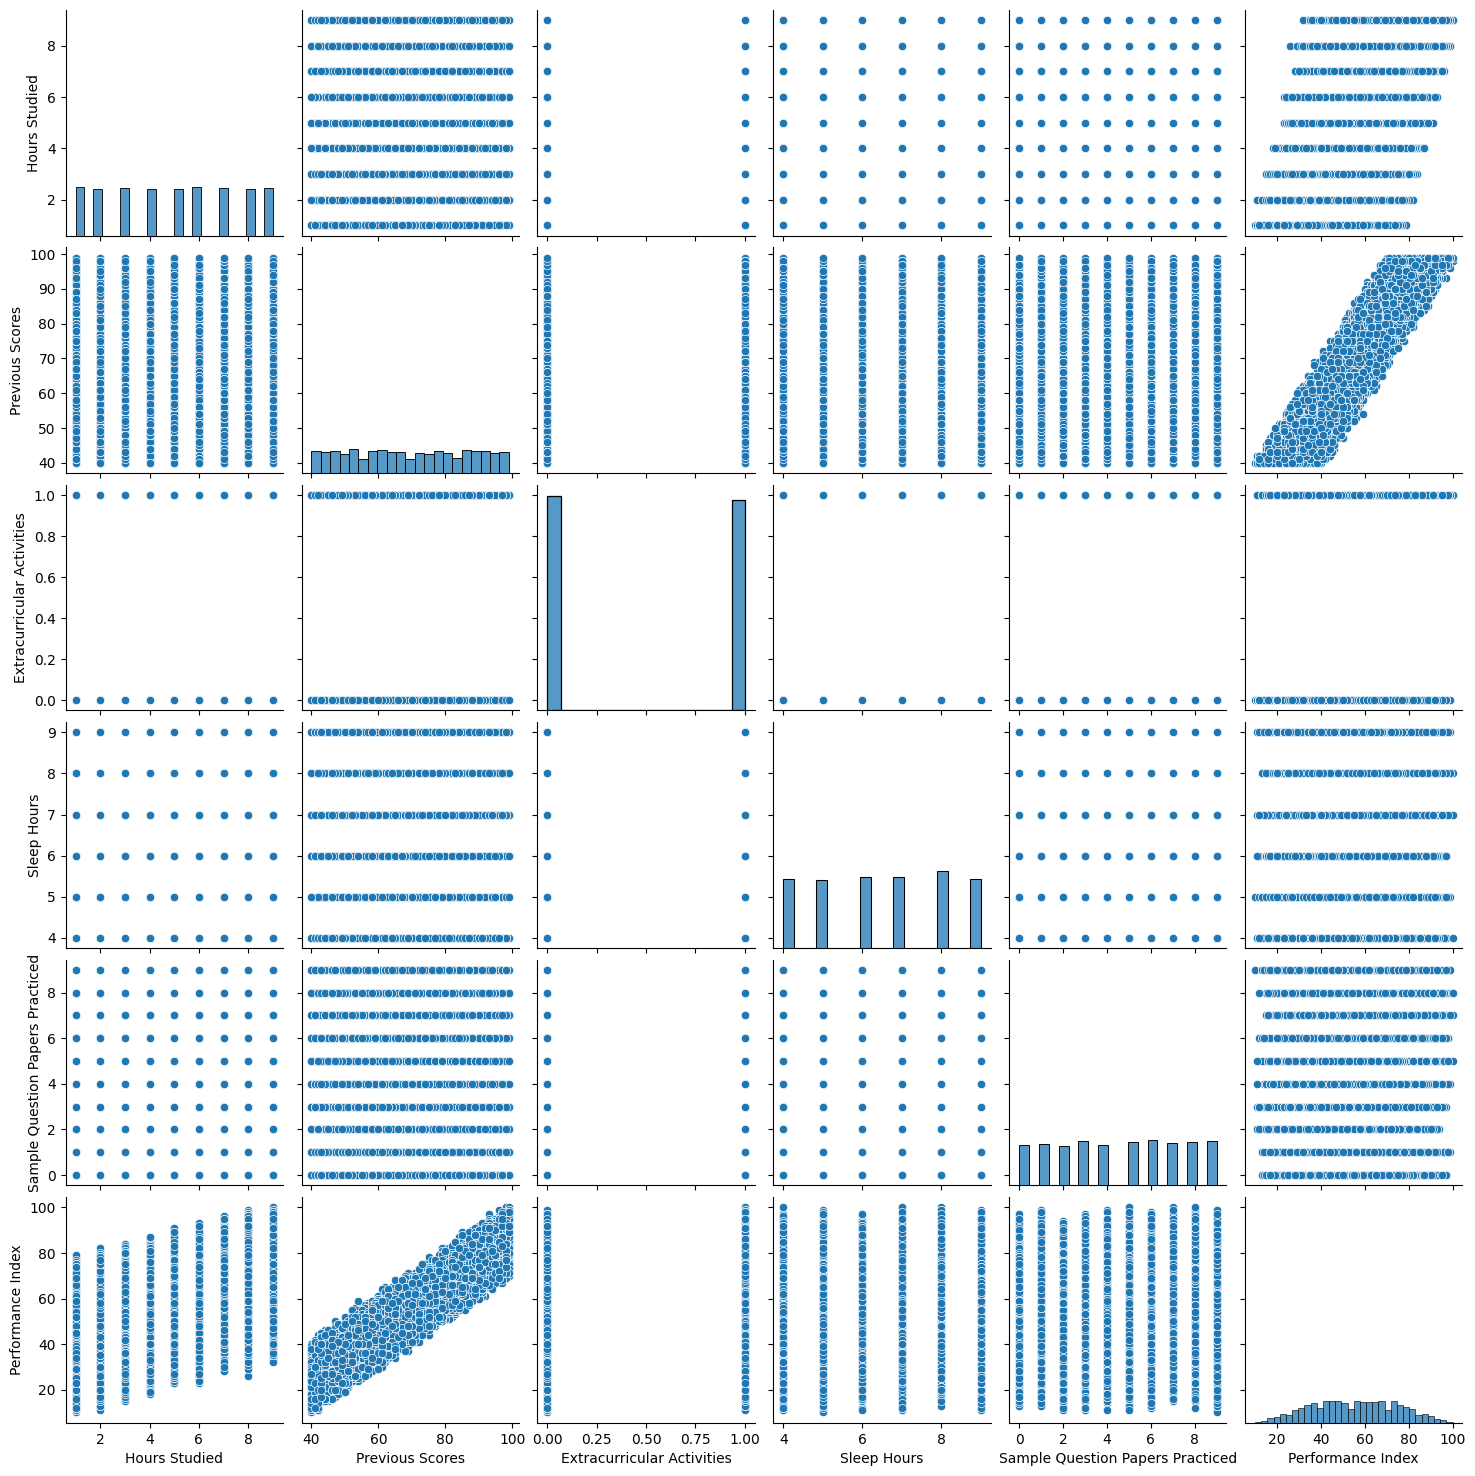

In [37]:
sns.pairplot(df)

Од овие scatterplots може да ја видиме линеарната врска меѓу features и target. Забележуваме дека најсилна линеарна врска има меѓу 'Previuos Scores' и 'Performance Index', што значи дека 'Previuos Scores' најмногу влијае на таргетот, однсно моделот ќе му даде голем коефициент, а пак другите features имаат помало влијание. Може да се каже дека линеарна врска има и кај 'Hours Studied' и 'Performance Index'.

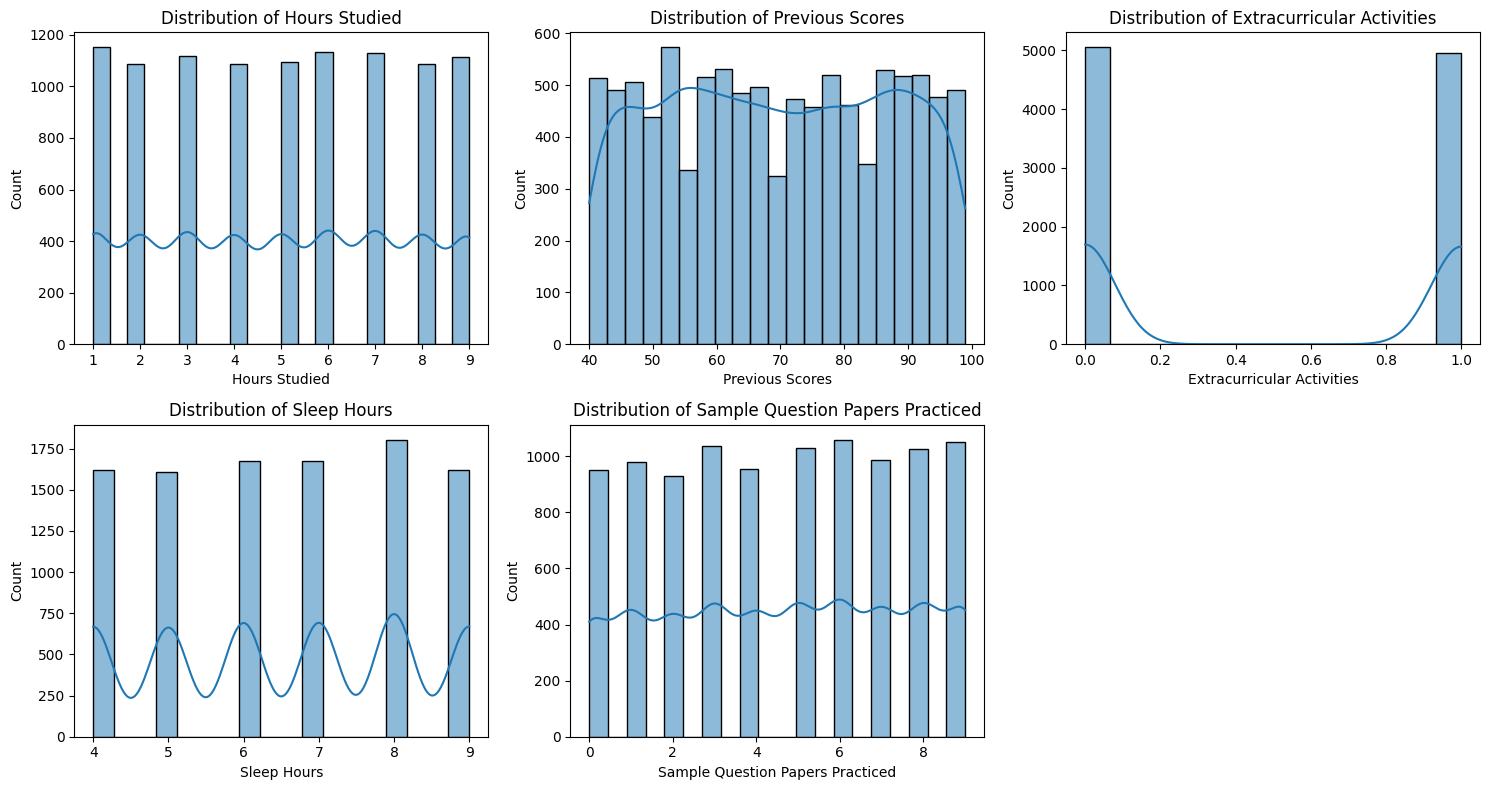

In [38]:
features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, f in enumerate(features):
    sns.histplot(df[f], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {f}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

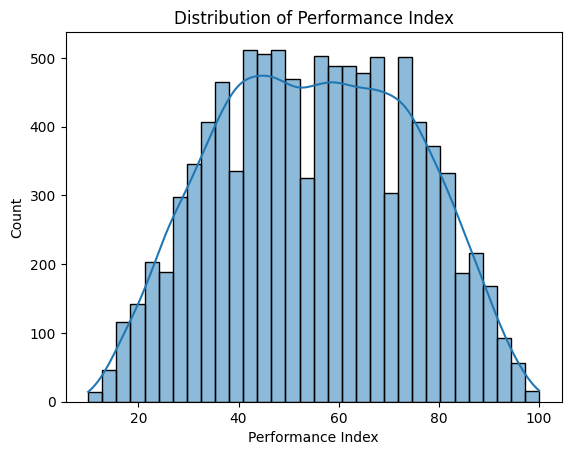

In [39]:
sns.histplot(df['Performance Index'], kde=True)
plt.title('Distribution of Performance Index')
plt.show()

Правиме хистограми за да видиме како се распределни вредностите на променливите. Од хистограмите може да видиме дали податоците се приближно нормално распределни.

In [40]:
X = df.drop('Performance Index', axis=1)
y=df['Performance Index']
reg = LinearRegression()
reg.fit(X, y)

LinearRegression()

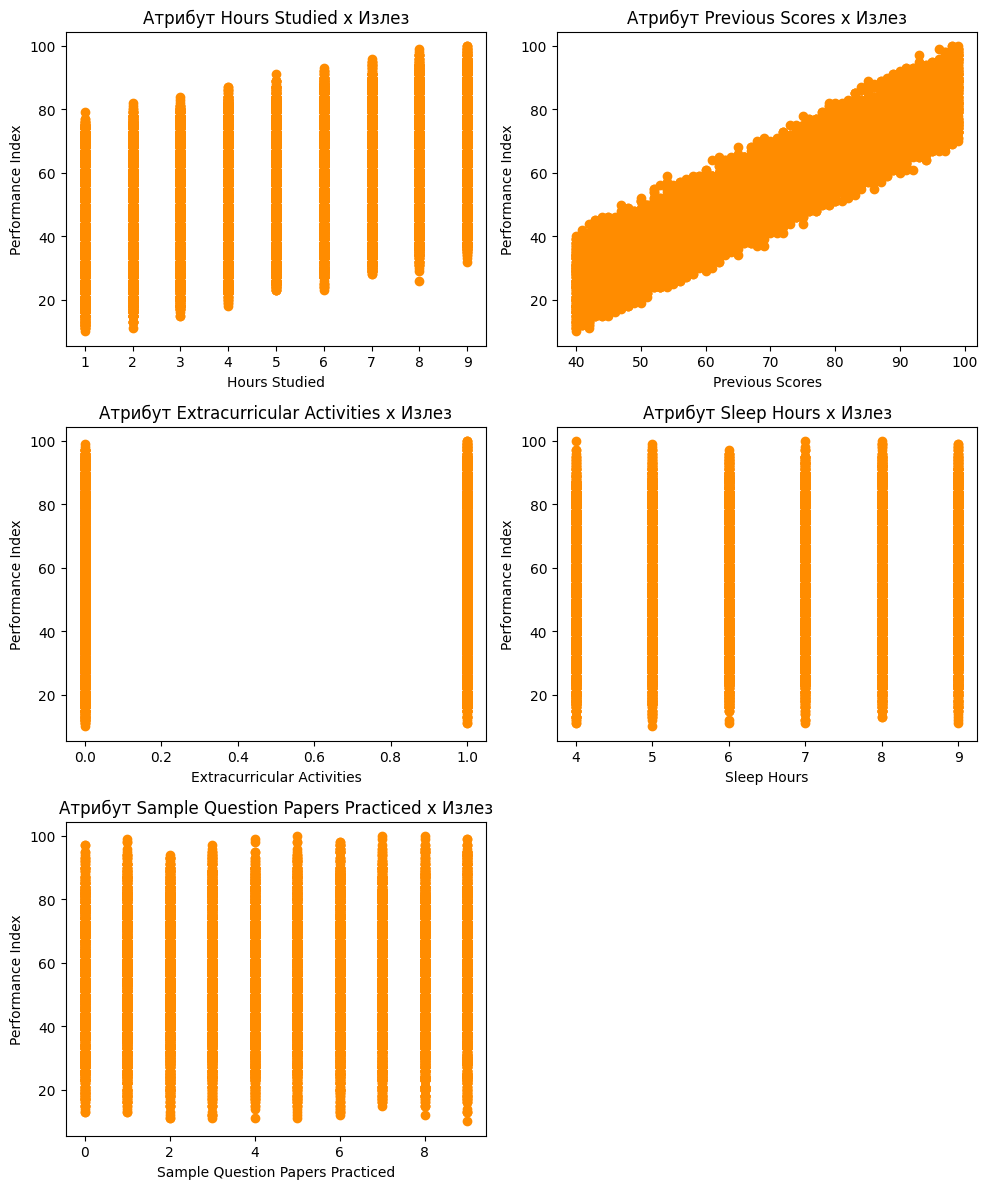

In [41]:
features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

number_of_features = len(features)

nrows = (number_of_features + 1) // 2
ncols = 2

fig = plt.figure(figsize=(10, nrows*4))

for feat_i in range(number_of_features):
    ax = plt.subplot(nrows, ncols, feat_i+1)
    plt.scatter(X.iloc[:, feat_i], y, color="darkorange")
    plt.xlabel(features[feat_i])
    plt.ylabel("Performance Index")
    plt.title(f"Атрибут {features[feat_i]} x Излез")

plt.tight_layout()
plt.show()

<Axes: >

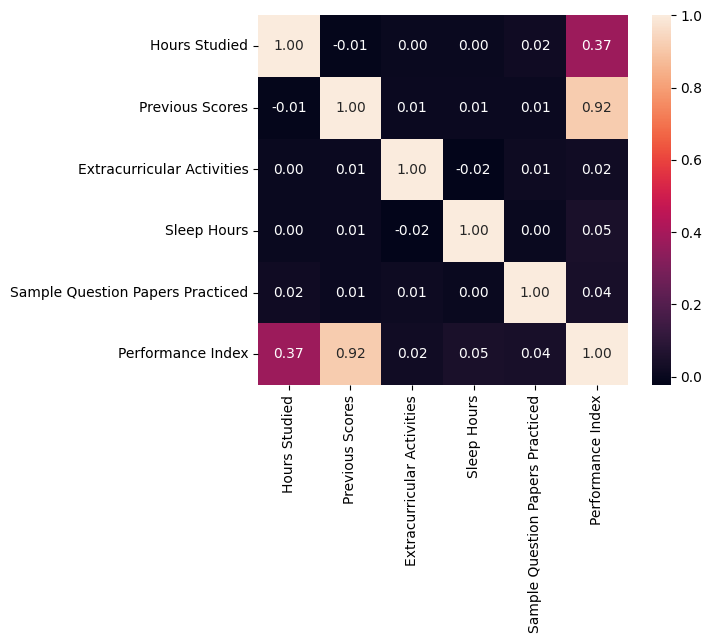

In [42]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True)

3. Min-Max нормализација


---



In [43]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Ги трансформираме сите вредности да бидат во ранг [0,1].

4. Регресиони модели


---



LinearRegression


---




In [44]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_linear)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred))

Коефициенти W:  [22.87161784 59.91566786  0.58171285  2.3983838   1.71354741]
Пресек W0:  11.561907234173418
Средна квадратна грешка: 4.066563824092734
Средна апсолутна грешка: 1.609043756404535
Корен на средна квадратна грешка: 2.0165722957763585
R-квадрат:  0.9890110607021135


W се тежините w1, w2, w3, w4, w5 за секоја од влезните променлви и тие ни покажуваат колку силно секоја една од нив влијае на таргетот. Втората, односно 'Previous Scoures' има најголемо влијание, што веќе го видовме тоа и кај scatterplots. Значи зголемувањето на 'Previous Scoures' за 1 еднициа го зголеми 'Performance Index' за 59.9 (додека другите се фиксни).

W0  е intercept, то ест предвидената вредност на Performance Index кога сите влезни променливи се 0.

MSE е грешката, односно колку моделот во просек бега од вистинските вредности.

MAE како мсе но не е квадратнат туку апсолутна.

R-квадрат ни кажува колку добро се предвидуваат податоците. Ако е приближно до 1, значи модлеот многу добро ја објаснува варијабилноста, ако е приближно до 0 занчи моделот не објаснува ништо.

Според добиените резултати, може да се заклучи дека влезните податоци многу добро ја објаснуваат 'Performance Index'.

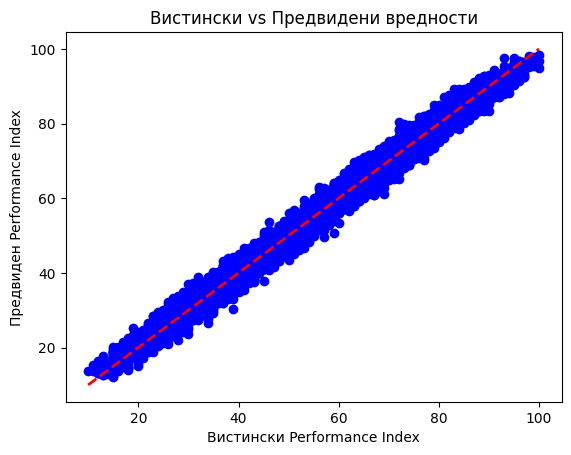

In [45]:
y_true = y.values.ravel()
y_pred = reg.predict(X).ravel()
plt.scatter(y_true, y_pred, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)  # линија y=x
plt.xlabel('Вистински Performance Index')
plt.ylabel('Предвиден Performance Index')
plt.title('Вистински vs Предвидени вредности')
plt.show()

Од овој скатерплот може да забележиме дека предвидените точки се еблиску до црвената линија, што значи дека моделот работи многу добро и дека предвидувањата се скоро идентични со вистинските вредности.

Ridge Regression


---



Коефициенти W:  [22.83984899 59.81642652  0.5818523   2.39603146  1.71239921]
Пресек W0:  11.629240528505171
Средна квадратна грешка: 4.076403885329378
Средна апсолутна грешка: 1.6108003575183412
Корен на средна квадратна грешка: 2.0190106204102487
R-квадрат:  0.9889844702340195


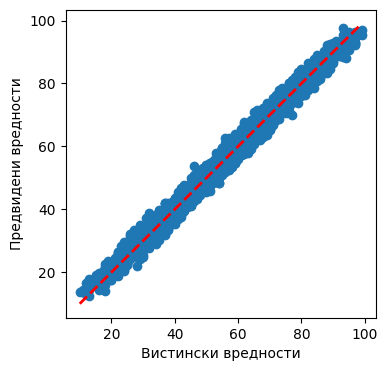

In [46]:
from sklearn.linear_model import Ridge
reg = Ridge(alpha=1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците

mse_ridge = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_ridge)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

RidgeCV


---



Средна квадратна грешка: 4.066591352762181


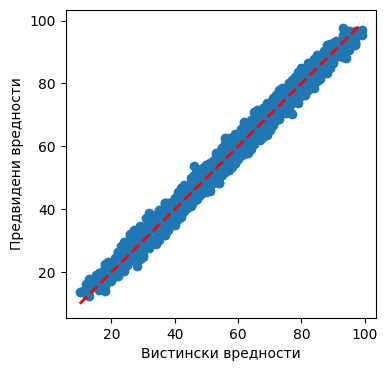

In [47]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(alphas=np.logspace(-3, 3, 50), store_cv_values=True)
ridgecv.fit(X_train, y_train)
y_pred = ridgecv.predict(X_test)

mse_ridgecv = mean_squared_error(y_test, y_pred)
print("Средна квадратна грешка:", mse_ridgecv)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # линија y=x
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Lasso Regression


---



Коефициенти W:  [21.93281129 58.76817406  0.17107308  1.53138147  0.74272139]
Пресек W0:  13.745683106183954
Средна квадратна грешка: 4.6358053655346465
Средна апсолутна грешка: 1.706248585370228
Корен на средна квадратна грешка: 2.15309204762236
R-квадрат:  0.9874728183394387


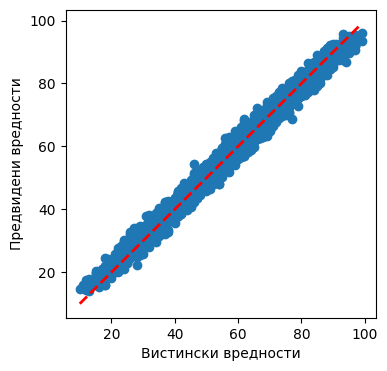

In [48]:
from sklearn.linear_model import Lasso
reg = Lasso(alpha = 0.1).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците

mse_lasso_01 = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_lasso_01)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Со alpha=0.1 , моделот не ги гледа некој features, односно губи информации, затоа MSE е поголема.

Коефициенти W:  [20.03849657 56.45026146  0.          0.          0.        ]
Пресек W0:  17.09584223285286
Средна квадратна грешка: 7.3231385284677115
Средна апсолутна грешка: 2.1373017812578765
Корен на средна квадратна грешка: 2.7061298062856687
R-квадрат:  0.980210927888904


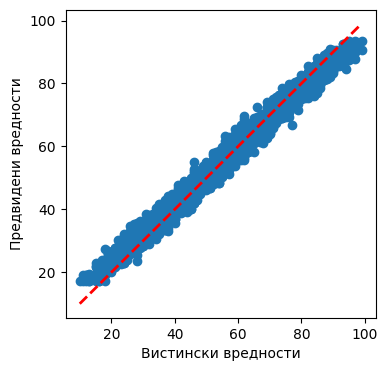

In [49]:
from sklearn.linear_model import Lasso
reg = Lasso(alpha = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците

mse_lasso_03 = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_lasso_03)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

Со уште поголема alpha, моделот ги доведува некои features до 0, па затоа MSE овдека е доста поголемо за разлика од претходните модели.

LassoCV


---



Средна квадратна грешка: 4.067901344749125


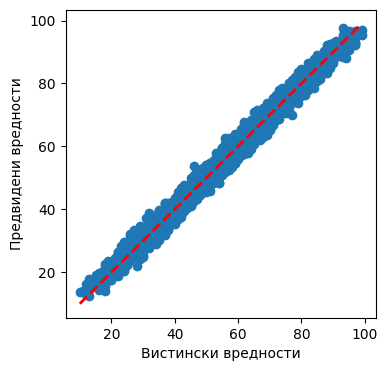

In [50]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=5000)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

mse_lassocv = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_lassocv)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

ElasticNet Regression


---



Коефициенти W:  [13.44387441 32.85620553  0.45701839  1.43647777  1.04628399]
Пресек W0:  30.727047192559272
Средна квадратна грешка: 78.28619669243317
Средна апсолутна грешка: 7.454933998546561
Корен на средна квадратна грешка: 8.847948727950065
R-квадрат:  0.7884498312263716


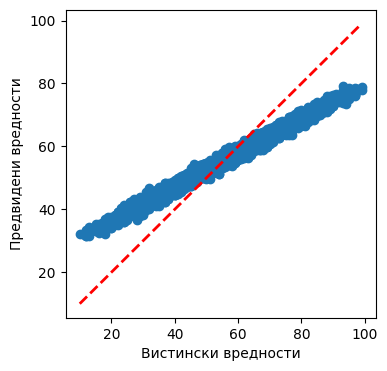

In [51]:
from sklearn.linear_model import ElasticNet
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците

mse_elastic_net = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_elastic_net)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

ElasticNet е комбинација од Ridge и Lasso. Lasso (L1) ги гаси некои features, a Ridge (L2) ги намалува коефициентите.

Средна квадратна грешка: 78.28619669243317, ова е преголемо, односно ElasticNet многу ги смалува коефициентите и губи информации.


Bayesian Ridge


---




Коефициенти W:  [22.8714559  59.91516186  0.58171357  2.39837181  1.71354157]
Пресек W0:  11.562250516819063
Средна квадратна грешка: 4.066609200462606
Средна апсолутна грешка: 1.6090516390033667
[2.05015536 2.05030131 2.0509194  ... 2.04998547 2.05194596 2.05015244]
3000
Корен на средна квадратна грешка: 2.016583546611101
R-квадрат:  0.9890109380830682


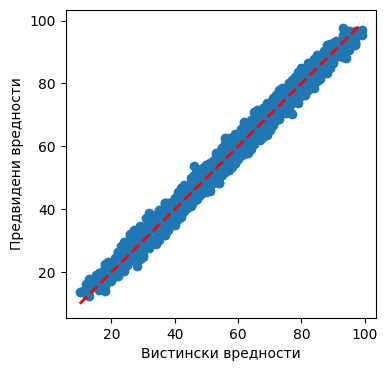

In [52]:
from sklearn.linear_model import BayesianRidge
reg = BayesianRidge().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred, y_std = reg.predict(X_test, return_std = True) # предвиди ги вредностите на тест податоците

mse_bayesian_ridge = mean_squared_error(y_test, y_pred)

print("Средна квадратна грешка:", mse_bayesian_ridge)
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print(y_std)
print(len(y_std))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test, y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

In [53]:
print("MSE на тест множеството:")
print("Linear Regression: ", mse_linear)
print("Ridge: ", mse_ridge)
print("RidgeCV: ", mse_ridgecv, " | оптимален alpha:", ridgecv.alpha_)
print("Lasso so alpha=0.1: ", mse_lasso_01)
print("Lasso so alpha=0.3: ", mse_lasso_03)
print("LassoCV: ", mse_lassocv, " | оптимален alpha:", lasso.alpha_)
print("ElasticNet: ", mse_elastic_net)
print("Bayesian Ridge: ", mse_bayesian_ridge)

MSE на тест множеството:
Linear Regression:  4.066563824092734
Ridge:  4.076403885329378
RidgeCV:  4.066591352762181  | оптимален alpha: 0.0030888435964774815
Lasso so alpha=0.1:  4.6358053655346465
Lasso so alpha=0.3:  7.3231385284677115
LassoCV:  4.067901344749125  | оптимален alpha: 0.001
ElasticNet:  78.28619669243317
Bayesian Ridge:  4.066609200462606


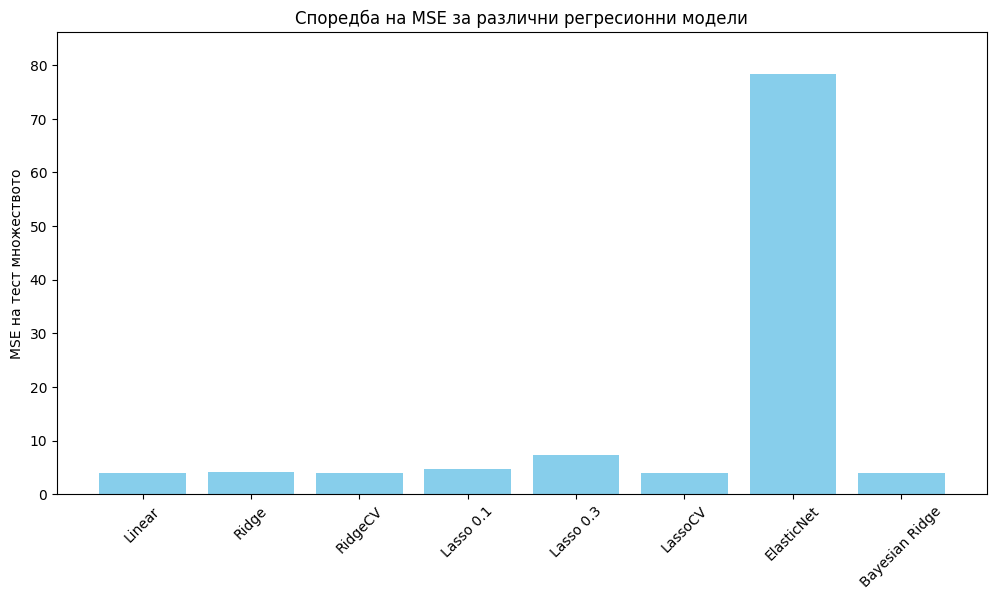

In [54]:
# Модели и нивните MSE
models = ['Linear', 'Ridge', 'RidgeCV', 'Lasso 0.1', 'Lasso 0.3', 'LassoCV', 'ElasticNet', 'Bayesian Ridge']
mse_values = [4.066563824092734, 4.076403885329378, 4.066591352762181,
              4.6358053655346465, 7.3231385284677115, 4.067901344749125,
              78.28619669243317, 4.066609200462606]

# Бар графикон
plt.figure(figsize=(12,6))
plt.bar(models, mse_values, color='skyblue')
plt.ylabel('MSE на тест множеството')
plt.title('Споредба на MSE за различни регресионни модели')
plt.xticks(rotation=45)
plt.ylim(0, max(mse_values)*1.1)
plt.show()

 Од добиените резултати може да се забележи дека Linear Regression, RidgeCV и LassoCV даваат речиси идентични вредности за MSE, што укажува дека податоците имаат силна линеарна зависност и нема потреба од значајна регуларизација.

 Оптималните вредности на параметарот alpha кај RidgeCV и LassoCV се многу мали, што дополнително потврдува дека моделите не страдаат од overfitting. Може да заклучиме дека колку е поголема вредноста за alpha, MSE се зголемува, однoсно губиме повеќе информации и Lasso почнува на некој начин да ги гаси некои features (им става 0).

 ElasticNet моделот покажува значително полоши резултати во однос на останатите модели, што укажува дека комбинацијата од L1 и L2 регуларизација со избраните параметри доведува до прекумерно намалување на коефициентите и губење на важни информации.

 Bayesian Ridge регресијата дава резултати речиси идентични на линеарната регресија, што дополнително потврдува дека податоците имаат стабилна линеарна зависност и не е потребна силна регуларизација.



---



Тука го гледаме влијанието на 'Hours Studied'. Може да се види дека скоро кај сите модели нема потреба од регуларизација, освен кај ElasticNet каде што добивме доста полош резултат, а тоа значи дека моделот мисли дека 'Hours Studied' има помало влијание.

In [55]:
Xi=X[:,0].reshape(-1,1)
print("Xi=", Xi)
print("y=",y)

lr = LinearRegression()
lr.fit(Xi, y)
lrsigma = np.sum((y - lr.predict(Xi))**2) /(N-2) # пресметка на варијансата на моделот

ridge = Ridge(alpha=1)
ridge.fit(Xi, y)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) /(N-2)

lasso = Lasso(alpha=0.1)
lasso.fit(Xi, y)
lassosigma = np.sum((y - lasso.predict(Xi))**2) /(N-2)

elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xi, y)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) /(N-2)

Bayes = BayesianRidge()
Bayes.fit(Xi, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Xi= [[0.75 ]
 [0.375]
 [0.875]
 ...
 [0.625]
 [1.   ]
 [0.75 ]]
y= 0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64
Коефициенти на моделите
Линеарна регресија:  [22.1845026]
Риџ регресија:  [22.1633438]
Ласо регресија:  [21.22982724]
Регресија на еластична мрежа: [13.8622585]
Баесова риџ регресија:  [22.17083664]


In [56]:
Xi=X[:,1].reshape(-1,1)
print("Xi=", Xi)
print("y=",y)

lr = LinearRegression()
lr.fit(Xi, y)
lrsigma = np.sum((y - lr.predict(Xi))**2) /(N-2) # пресметка на варијансата на моделот

ridge = Ridge(alpha=1)
ridge.fit(Xi, y)
ridgesigma = np.sum((y - ridge.predict(Xi))**2) /(N-2)

lasso = Lasso(alpha=0.1)
lasso.fit(Xi, y)
lassosigma = np.sum((y - lasso.predict(Xi))**2) /(N-2)

elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(Xi, y)
elasticsigma = np.sum((y - elastic.predict(Xi))**2) /(N-2)

Bayes = BayesianRidge()
Bayes.fit(Xi, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Регресија на еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Xi= [[1.        ]
 [0.71186441]
 [0.18644068]
 ...
 [0.72881356]
 [0.96610169]
 [0.57627119]]
y= 0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64
Коефициенти на моделите
Линеарна регресија:  [59.81636539]
Риџ регресија:  [59.74721271]
Ласо регресија:  [58.65894433]
Регресија на еластична мрежа: [35.0280649]
Баесова риџ регресија:  [59.81520527]


Од ова се гледа дека 'Previuos Scores' има уште поголемо влијание.